In [5]:
import os
import sys
import shutil
import os
from boar.running import run_notebook

In [2]:
path_data = os.path.join(os.getcwd(), "data")
subfolders = [ f.path for f in os.scandir(path_data) if f.is_dir() ]

In [3]:
for f in subfolders:
    print(f)

D:\Promotion\neurolib\GUI\gui\data\.ipynb_checkpoints
D:\Promotion\neurolib\GUI\gui\data\00000
D:\Promotion\neurolib\GUI\gui\data\00001
D:\Promotion\neurolib\GUI\gui\data\00010
D:\Promotion\neurolib\GUI\gui\data\00011
D:\Promotion\neurolib\GUI\gui\data\00100
D:\Promotion\neurolib\GUI\gui\data\00101
D:\Promotion\neurolib\GUI\gui\data\00110
D:\Promotion\neurolib\GUI\gui\data\00111
D:\Promotion\neurolib\GUI\gui\data\01000
D:\Promotion\neurolib\GUI\gui\data\01001
D:\Promotion\neurolib\GUI\gui\data\01010
D:\Promotion\neurolib\GUI\gui\data\01011
D:\Promotion\neurolib\GUI\gui\data\01100
D:\Promotion\neurolib\GUI\gui\data\01101
D:\Promotion\neurolib\GUI\gui\data\01110
D:\Promotion\neurolib\GUI\gui\data\01111
D:\Promotion\neurolib\GUI\gui\data\10000
D:\Promotion\neurolib\GUI\gui\data\10001
D:\Promotion\neurolib\GUI\gui\data\10010
D:\Promotion\neurolib\GUI\gui\data\10011
D:\Promotion\neurolib\GUI\gui\data\10100
D:\Promotion\neurolib\GUI\gui\data\10101
D:\Promotion\neurolib\GUI\gui\data\10110
D:\

## Delete subfolders in data

In [ ]:
# delete specific subfolders
delete = ['11111']

for d in delete:
    path_delete = os.path.join(path_data, d)
    shutil.rmtree(path_delete)

In [ ]:

# delete all but particular subfolders
keep = ['.ipynb_checkpoints', '00001']

subfolders = [ f.path for f in os.scandir(path_data) if f.is_dir() ]

for s in subfolders:
    case = s.split(os.sep)[-1]
    if case not in keep:
        print("delete case ", case)
        path_delete = os.path.join(path_data, case)
        shutil.rmtree(path_delete)

In [ ]:

# delete results from specific subfolders
delete = ['00001']

for d in delete:
    file_delete = os.path.join(path_data, d, 'control_init_' + d + '.pickle')
    if os.path.isfile(file_delete):
        os.remove(file_delete)
    file_delete = os.path.join(path_data, d, 'control_0_' + d + '.pickle')
    if os.path.isfile(file_delete):
        os.remove(file_delete)

In [ ]:
# delete results from all but particular subfolders
keep = ['.ipynb_checkpoints', '00001']

subfolders = [ f.path for f in os.scandir(path_data) if f.is_dir() ]

for s in subfolders:
    case = s.split(os.sep)[-1]
    if case not in keep:
        print("delete case ", case)
        file_delete = os.path.join(path_data, case, 'control_init_' + case + '.pickle')
        if os.path.isfile(file_delete):
            os.remove(file_delete)
        file_delete = os.path.join(path_data, case, 'control_0_' + case + '.pickle')
        if os.path.isfile(file_delete):
            os.remove(file_delete)

## Create folders for data and copy data and scripts¶

In [4]:
folders = []
for i in range(32):
    fol = str(bin(i)[2:])
    while len(fol) < 5:
        fol = '0' + fol
    folders.append(fol)
    
print(folders)

['00000', '00001', '00010', '00011', '00100', '00101', '00110', '00111', '01000', '01001', '01010', '01011', '01100', '01101', '01110', '01111', '10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000', '11001', '11010', '11011', '11100', '11101', '11110', '11111']


In [ ]:

# create all
for fol in folders:
    create_path = os.path.join(path_data, fol)
    if not os.path.isdir(create_path):
        print("create directory ", fol)
        os.mkdir(create_path)

In [ ]:
# create particular
create= ['11111']

for c in create:
    create_path = os.path.join(path_data, c)
    if not os.path.isdir(create_path):
        print("create directory ", c)
        os.mkdir(create_path)

In [6]:
# Copy data and script to particular folder

copy_from = '00100'
copy_to = ['00101', '00110', '00111',
           '01100', '01101', '01110', '01111',
           '10100', '10101', '10110', '10111',
           '11100', '11101', '11110', '11111']

copy_file = ['bi.pickle', 'data.ipynb', 'plots.ipynb']

for c in copy_to:
    copy_from_path = os.path.join(path_data, copy_from)
    copy_to_path = os.path.join(path_data, c)
    if not os.path.isdir(copy_to_path):
        print("directory does not exist, create")
        os.mkdir(copy_to_path)
            
    for cf in copy_file:
        copy_from_file = os.path.join(copy_from_path, cf)
        copy_to_file = os.path.join(copy_to_path, cf)
        shutil.copyfile(copy_from_file, copy_to_file)

In [ ]:
# Copy data and script to all folders

copy_from = '11011'
copy_to = folders

copy_file = ['bi.pickle', 'data.ipynb', 'plots.ipynb']

for c in copy_to:
    if c == copy_from:
        continue
    copy_from_path = os.path.join(path_data, copy_from)
    copy_to_path = os.path.join(path_data, c)
    if not os.path.isdir(copy_to_path):
        print("directory does not exist, create")
        os.mkdir(copy_to_path)
            
    for cf in copy_file:
        copy_from_file = os.path.join(copy_from_path, cf)
        copy_to_file = os.path.join(copy_to_path, cf)
        shutil.copyfile(copy_from_file, copy_to_file)

D:\Promotion\neurolib\GUI\gui
--------------------------------------------------
Cell 0
--------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes

#path = os.path.join(os.getcwd(), "plots")


--------------------------------------------------
Cell 1
--------------------------------------------------
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])


D:\Promotion\neurolib\GUI\gui\data\00100
0
--------------------------------------------------
Cell 2
--------------------

-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006
--------------------------------------------------
Cell 11
--------------------------------------------------
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur

RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  1.9869117256937736
RUN  2 , total integrated cost =  0.594377536188087
RUN  3 , total integrated cost =  0.15624801245226513
RUN  4 , total integrated cost =  0.08394367845745448
RUN  5 , total integrated cost =  0.06570676753111031
RUN  6 , total integrated cost =  0.06354525315399581
RUN  7 , total integrated cost =  0.061855613618930425
RUN  8 , total integrated cost =  0.061241487469426314
RUN  9 , total integrated cost =  0.06051835157438963
RUN  10 , total integrated cost =  0.05996937602545212
RUN  11 , total integrated cost =  0.05901180665623061
RUN  12 , total integrated cost =  0.05798906682242131
RUN  13 , total integrated cost =  0.055203419551702035
RUN  14 , total integrated cost =  0.051814040653180855
RUN  15 , total integrated cost =  0.05173280325522403
RUN  16 , total integrated cost =  0.05146174232774002
RUN  17 , total integrated cost =  0.0513051

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  104 , total integrated cost =  0.04922787039549836
Improved over  104  iterations in  18.204116  seconds by  99.99971951765838  percent.
Problem in initial value trasfer:  sigmae_f 1.5670499152745643 1.566073397041382
Problem in initial value trasfer:  tau_exc 16.31396894491882 16.32645709720909
weight =  3565286.834878059
set cost params:  1.0 0.0 3565286.834878059
precision variables =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17342.960101802342
Gradient descend method:  None
RUN  1 , total integrated cost =  14737.633921683202
RUN  2 , total integrated cost =  14735.32064748037
RUN  3 , total integrated cost =  14731.795382176182
RUN  4 , total integrated cost =  14703.36944246991
RUN  5 , total integrated cost =  14693.477781018375
RUN  6 , total integrated cost =  14692.66682626958
RUN  7 , total integrated cost =  14690.108900182575
RUN  8 , total integrated cost =  14667.110992413707
RUN  9 , total integrat

...

130


D:\Promotion\neurolib\neurolib\utils\plotFunctions.py:778: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


143


D:\Promotion\neurolib\neurolib\utils\plotFunctions.py:778: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


--------------------------------------------------
Cell 9
--------------------------------------------------
initVars_2, target_2 = set_target_init(exc_2, inh_2, max_I, aln, dur)

path2 = path_directory + os.sep + '2max'
print(path2)

try:
    os.stat(path2)
except:
    os.mkdir(path2) 

for i in range(len(exc_2)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_2[i] * 5.
    aln.params.mui_ext_mean = inh_2[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in inh_:
            #print(i, j)
            if exc_2[i] == ext_exc[j] and inh_2[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_rate(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_2[i], target_2[i], path2, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["Initial guess", "Optimal control"], print

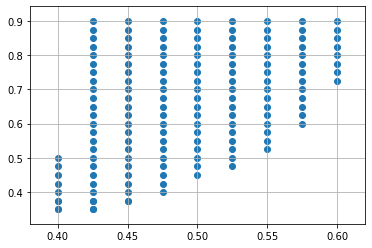

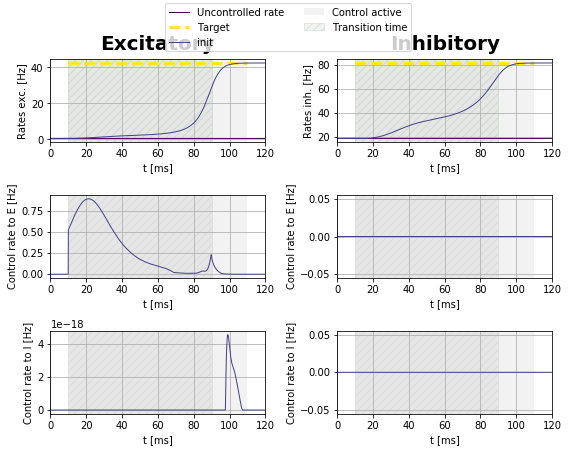

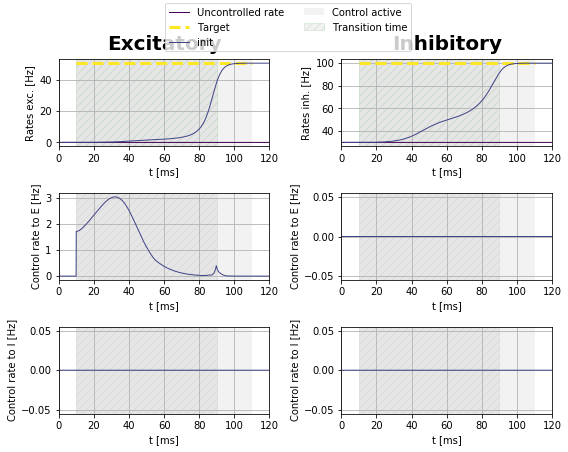

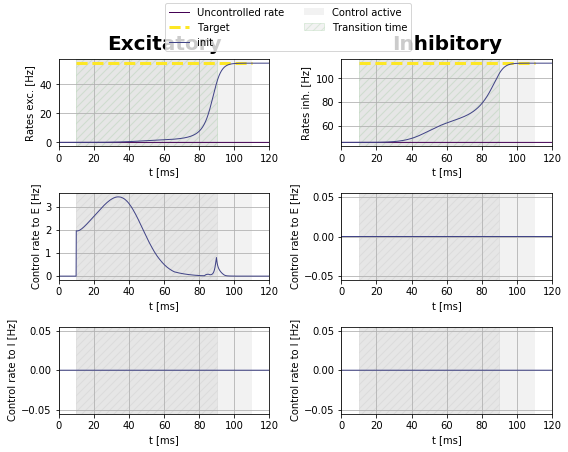

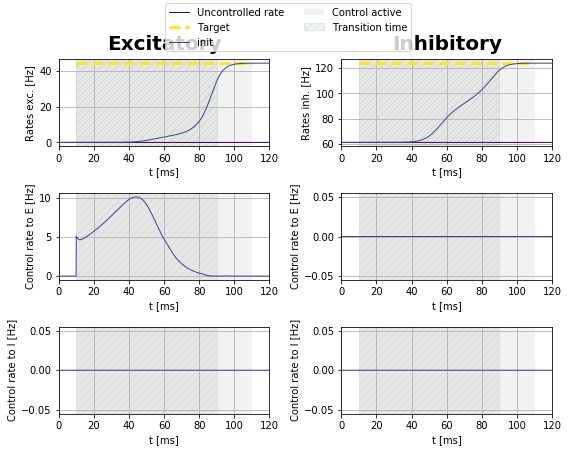

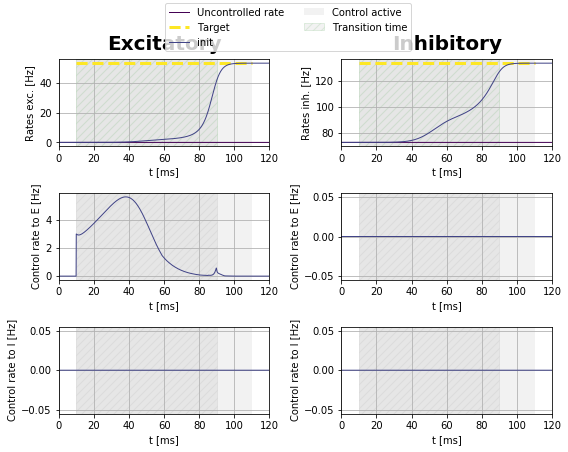

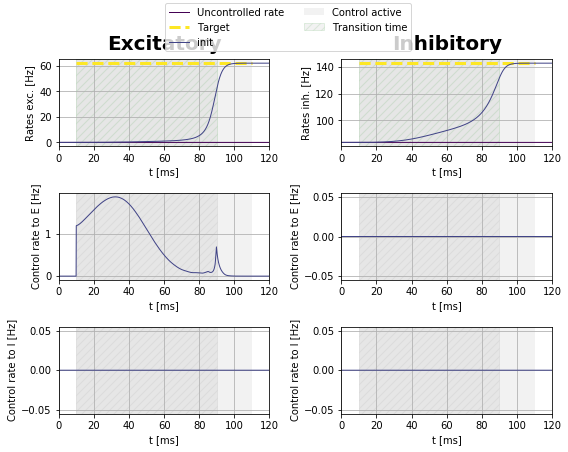

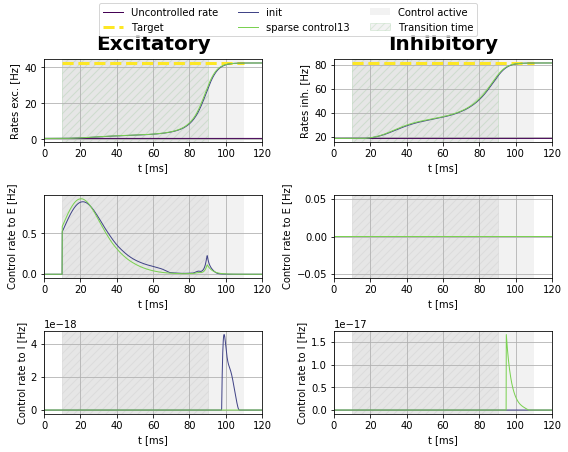

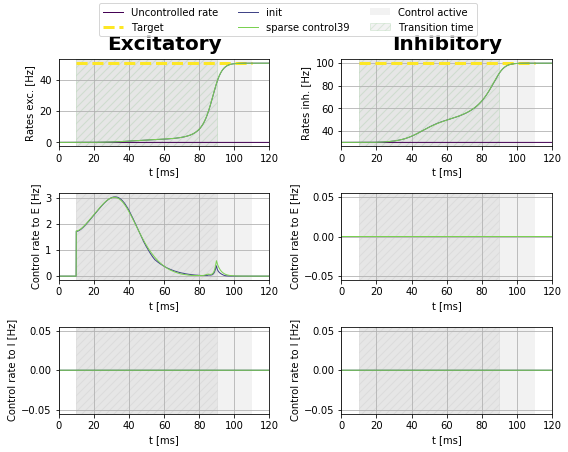

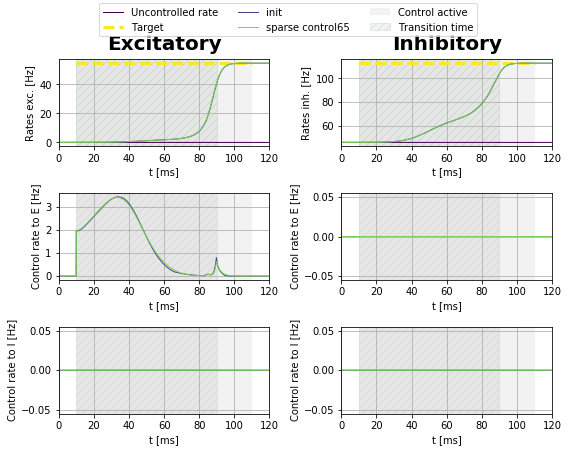

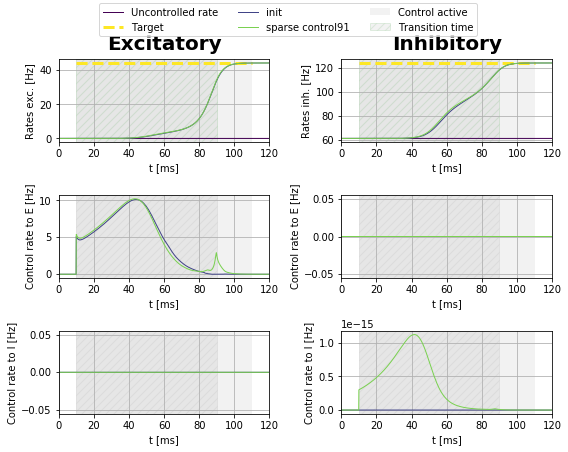

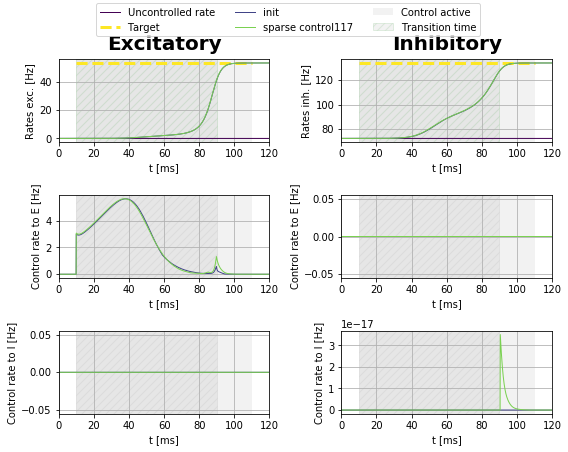

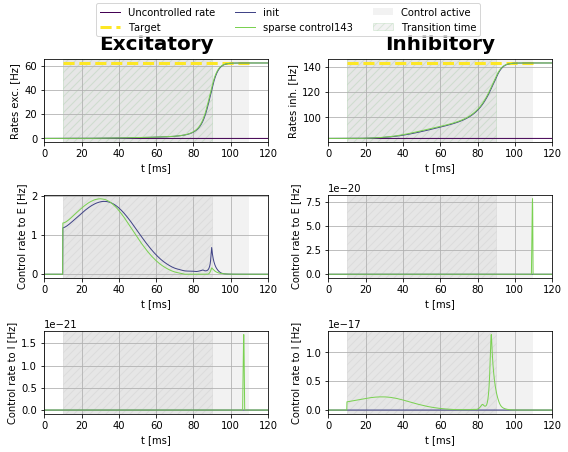

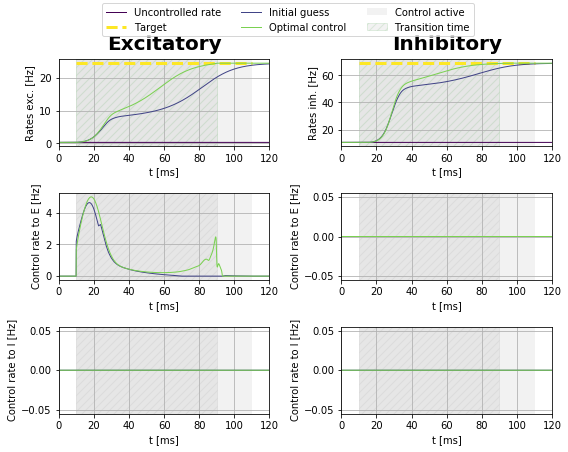

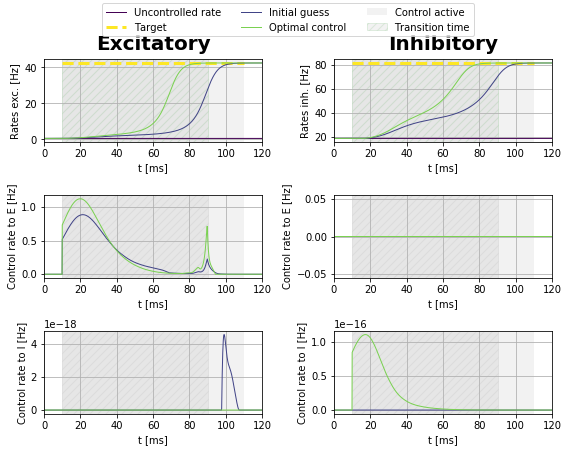

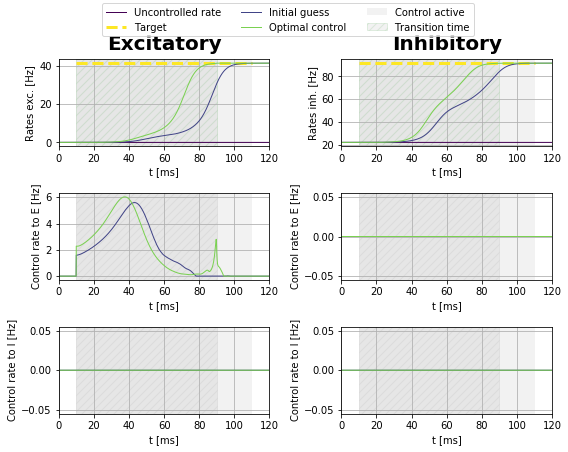

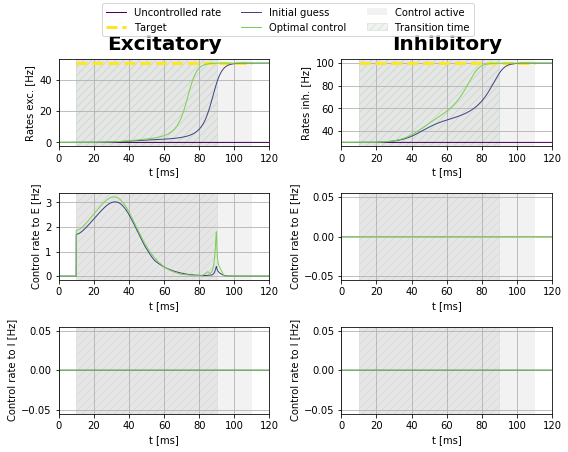

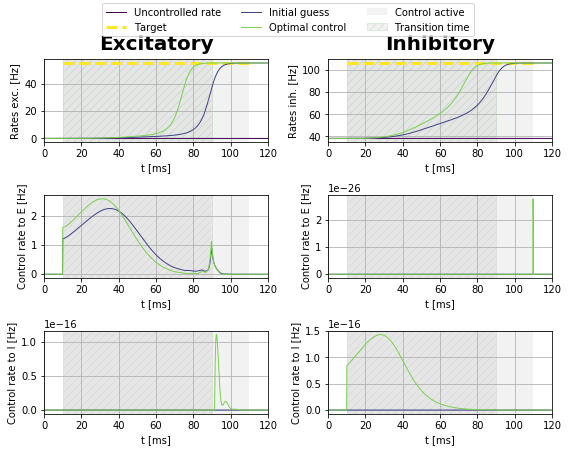

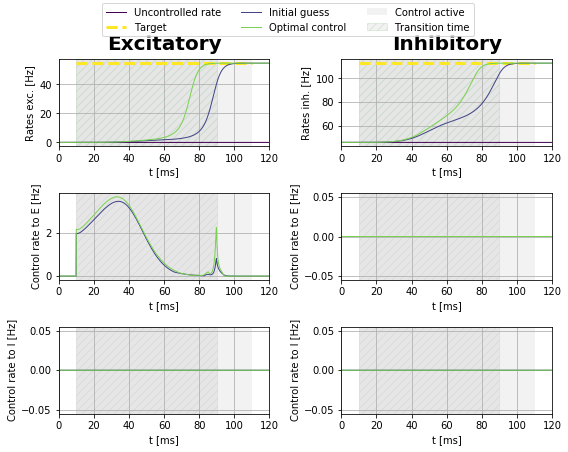

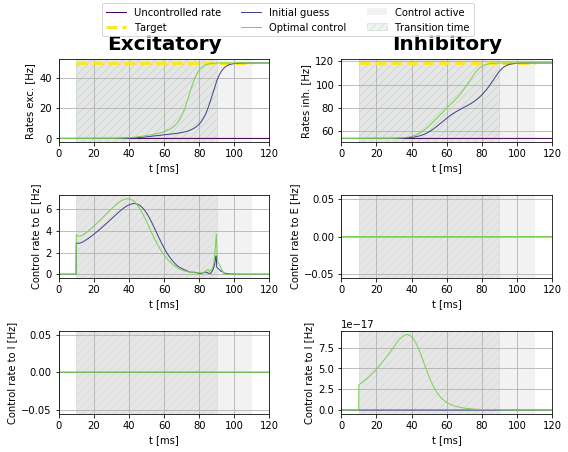

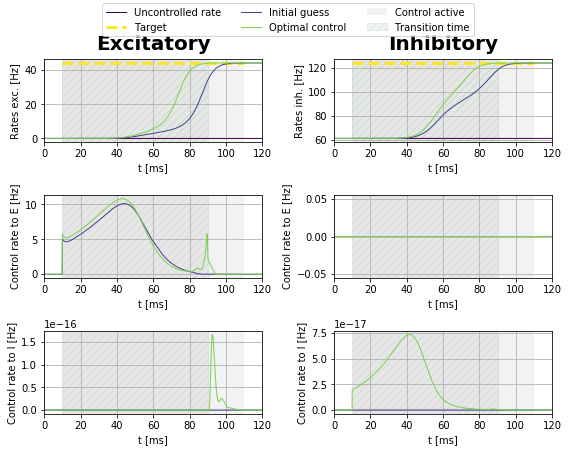

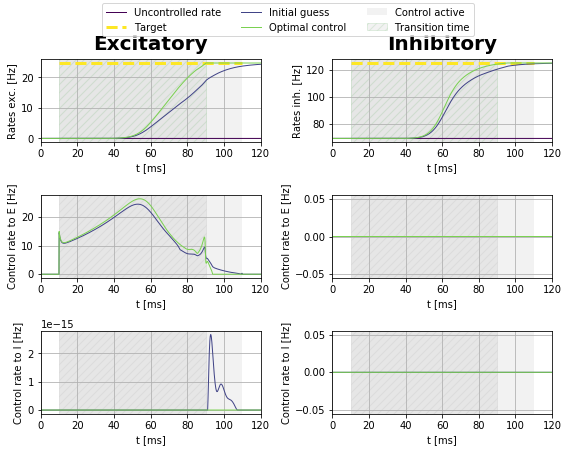

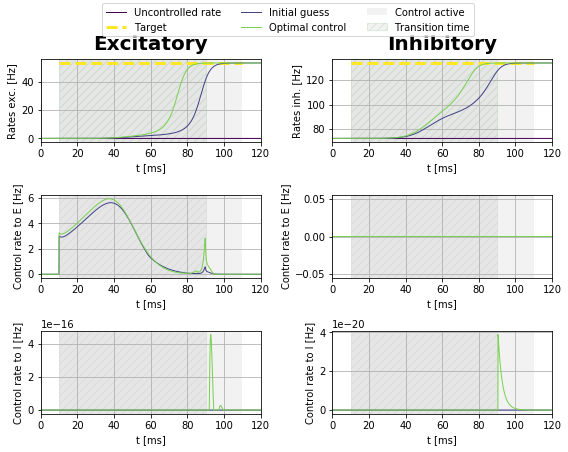

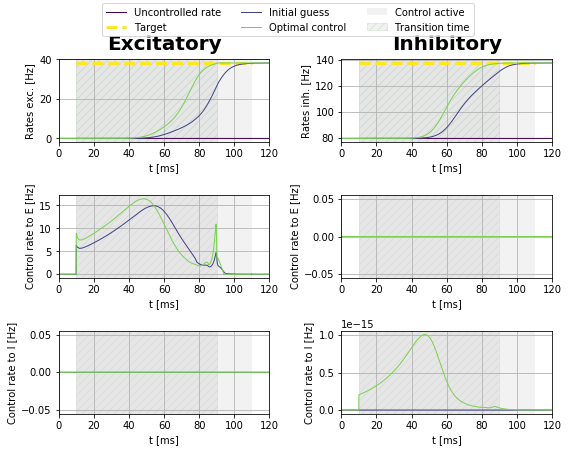

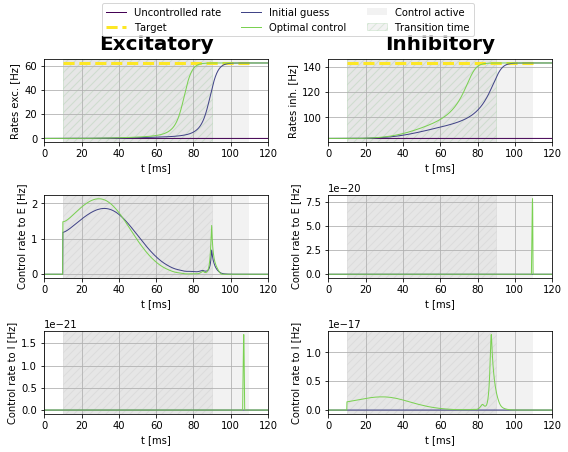

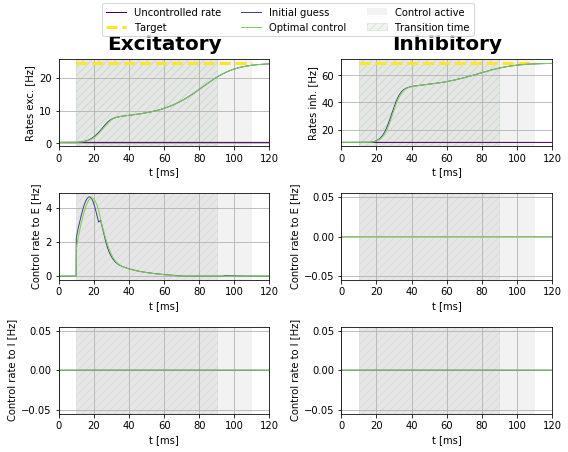

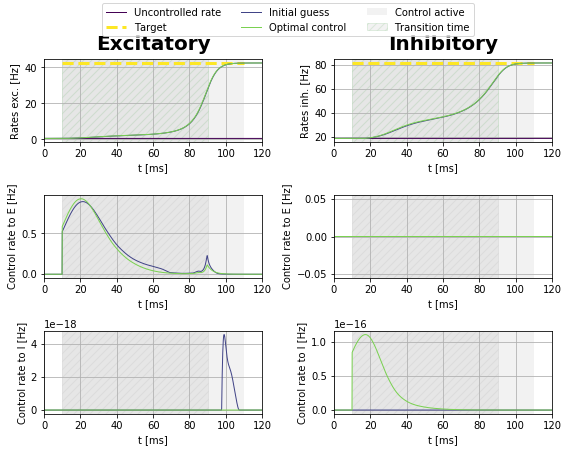

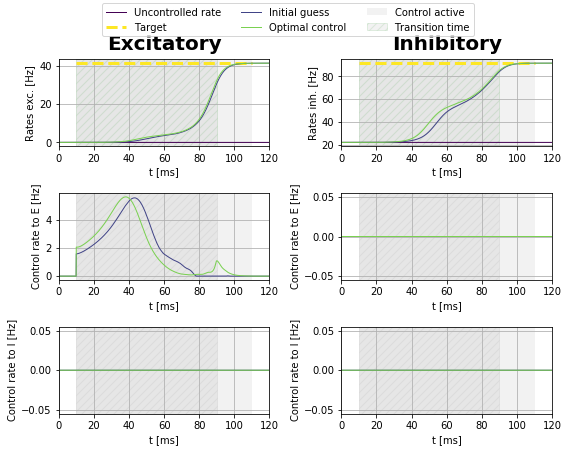

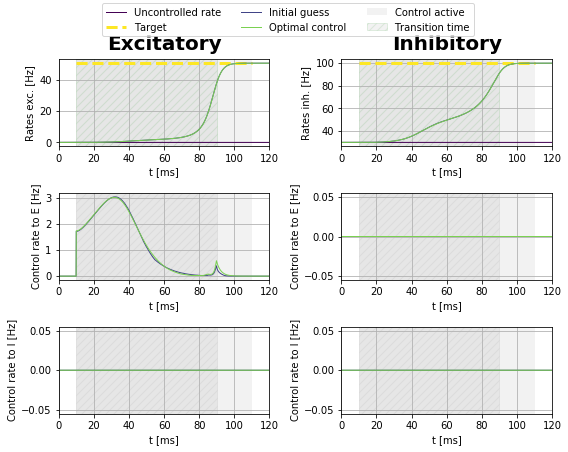

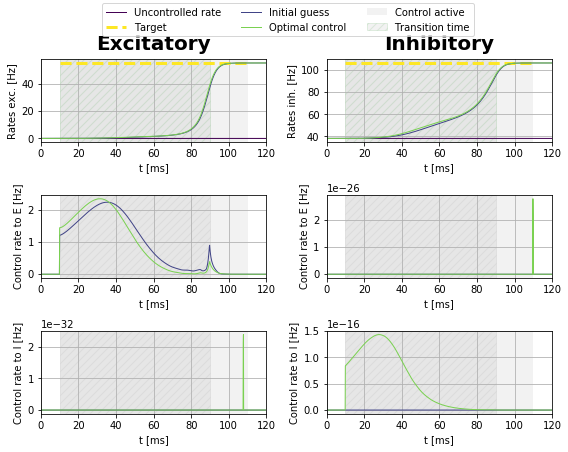

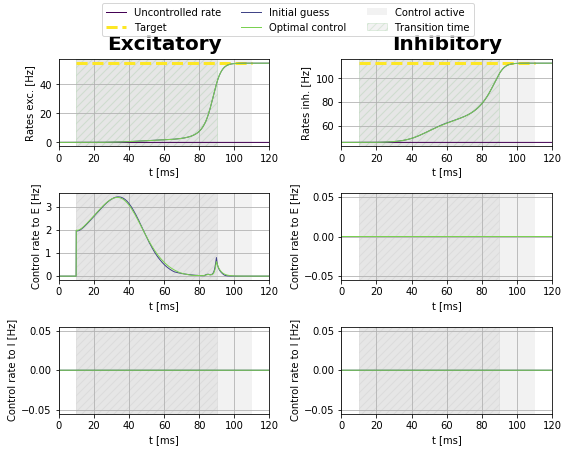

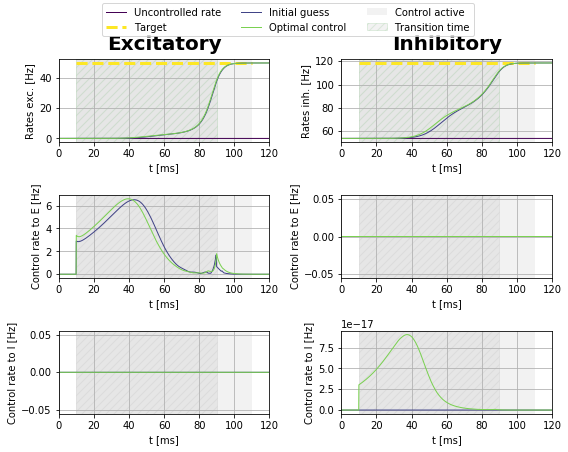

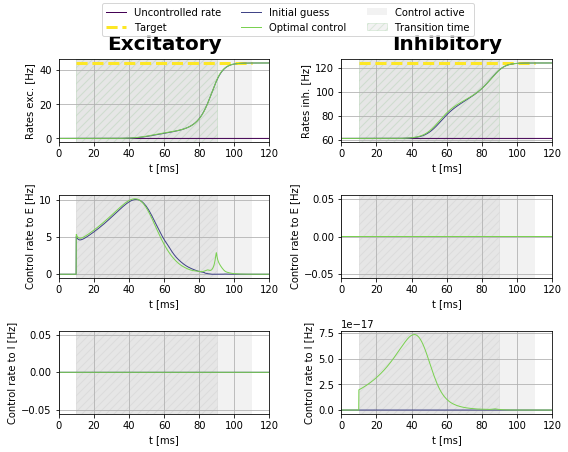

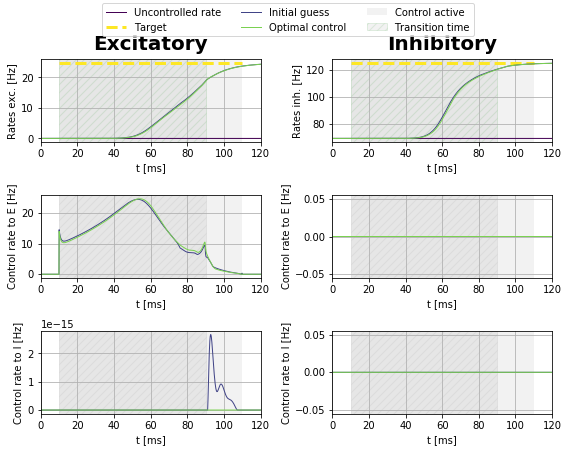

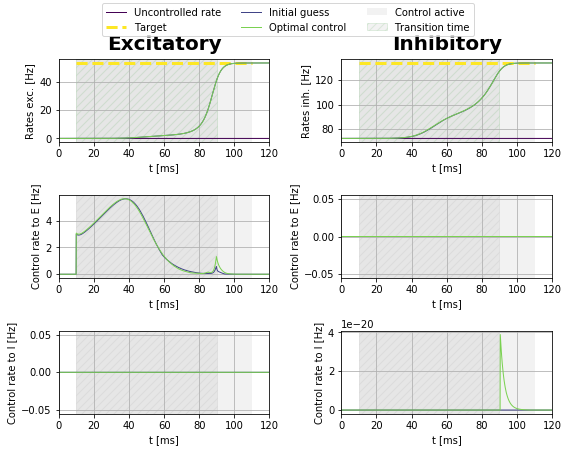

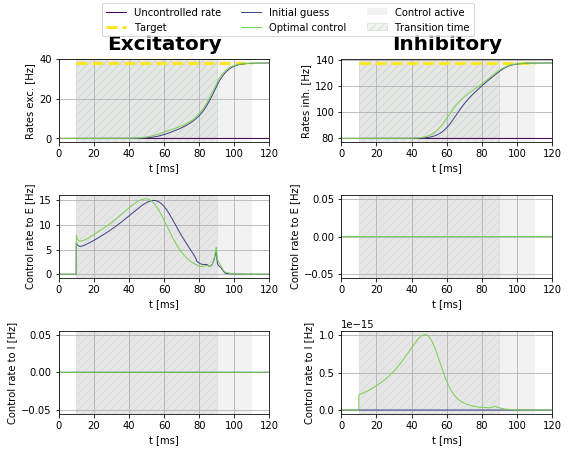

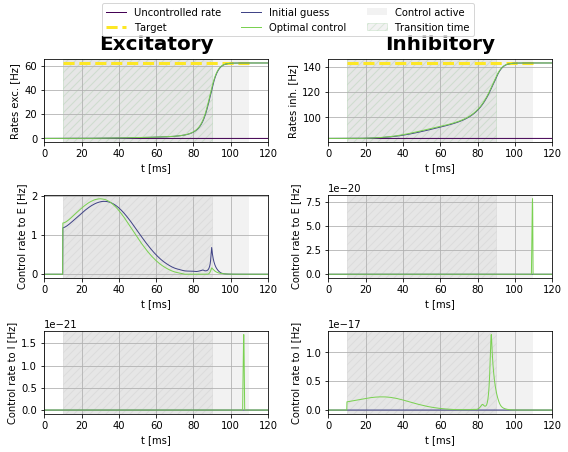

In [8]:
print(os.getcwd())

run_cases = [
    '00100'#, '00101', '00110', '00111',
    #'01100', '01101', '01110', '01111',
    #'10100', '10101', '10110', '10111',
    #'11100', '11101', '11110', '11111'
            ] 
if 'data' not in os.getcwd():
    os.chdir('data' + os.sep)
    
for run_ in run_cases:
    os.chdir(run_)
    outputs = run_notebook('data.ipynb')
    outputs = run_notebook('plots.ipynb')
    os.chdir('..')